# Week 6 — Autoencoder for Image Denoising on MNIST

**Rudra Mehta**

## Objective

The objective of this project is to build and evaluate deep learning-based autoencoders for removing noise from MNIST handwritten digit images. Each model receives a **noisy image as input** and attempts to reconstruct the corresponding **clean image**.

## Experimental Approach

To examine how different autoencoder architectures influence image denoising performance, three models will be developed and compared:

1. **Dense Autoencoder** — A fully connected baseline model that flattens the input image, compresses it into a lower-dimensional latent representation, and reconstructs the clean image.

2. **Convolutional Autoencoder** — A spatially aware architecture that uses convolutional layers to learn local image features while preserving the two-dimensional structure of MNIST digits.

3. **Advanced Skip-Connection Autoencoder** — A deeper U-Net-inspired architecture that incorporates skip connections and batch normalization to better preserve fine spatial details during reconstruction. The model also explores an enhanced training strategy using on-the-fly noise augmentation and a reconstruction objective designed to improve perceptual image quality.

## Evaluation Strategy

The models will be evaluated using both **visual and quantitative analysis**. The denoised outputs will be compared with the original clean images using:

* **Mean Squared Error (MSE)** — Measures pixel-level reconstruction error.
* **Peak Signal-to-Noise Ratio (PSNR)** — Measures reconstruction quality relative to image noise.
* **Structural Similarity Index (SSIM)** — Measures structural and perceptual similarity between reconstructed and clean images.

Training behavior, denoising performance, and computational efficiency will also be assessed to provide a fair comparison of the three architectures.

The final objective is to determine which architecture achieves the best balance between **noise removal, structural preservation, reconstruction quality, and computational efficiency** for MNIST image denoising.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)


print("=" * 70)
print("ENVIRONMENT SETUP")
print("=" * 70)

print(f"TensorFlow Version : {tf.__version__}")

gpu_devices = tf.config.list_physical_devices("GPU")

if gpu_devices:
    print(f"GPU Available      : Yes")
    print(f"GPU Device(s)      : {gpu_devices}")
else:
    print("GPU Available      : No (Training will use CPU)")

print(f"Random Seed        : {SEED}")

print("\nEnvironment setup completed successfully.")

ENVIRONMENT SETUP
TensorFlow Version : 2.20.0
GPU Available      : Yes
GPU Device(s)      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Random Seed        : 42

Environment setup completed successfully.


### Observation

The TensorFlow environment was configured successfully with TensorFlow version 2.20.0. GPU acceleration is available and enabled, allowing the autoencoder models to be trained efficiently. A fixed random seed of 42 was also initialized to improve the reproducibility of the experimental results. The environment is now ready for loading and preprocessing the MNIST dataset.

# Step 2: Load and Preprocess the MNIST Dataset

The **MNIST handwritten digit dataset** is loaded using the built-in Keras dataset loader. The dataset includes **60,000 training images** and **10,000 test images**, with each image representing a handwritten digit from 0 to 9 at a resolution of **28 × 28 pixels**.

Using the Keras loader allows easy access to the standard MNIST dataset in Google Colab without the need for additional Kaggle API configuration.

The images will be normalized to the range **[0, 1]** to improve numerical stability during neural network training. Since the objective is image denoising rather than classification, the digit class labels are not needed for model training.

The clean images will later be used as the **target outputs**, while artificially corrupted versions of these images will be used as the **inputs** to the autoencoder models.


In [2]:
print("=" * 70)
print("LOADING AND PREPROCESSING MNIST DATASET")
print("=" * 70)

# Load MNIST Dataset

(x_train, _), (x_test, _) = mnist.load_data()

print("\nMNIST dataset loaded successfully.")

print(f"\nOriginal Training Shape : {x_train.shape}")
print(f"Original Test Shape     : {x_test.shape}")

# Normalize Pixel Values to [0, 1]

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add Channel Dimension
# Shape: (samples, height, width) -> (samples, height, width, channels)

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)


# Dataset Summary

print("\n" + "-" * 70)
print("PREPROCESSED DATASET SUMMARY")
print("-" * 70)

print(f"Training Images        : {x_train.shape[0]:,}")
print(f"Test Images            : {x_test.shape[0]:,}")

print(f"Training Data Shape    : {x_train.shape}")
print(f"Test Data Shape        : {x_test.shape}")

print(f"Image Dimensions       : {x_train.shape[1]} x {x_train.shape[2]}")
print(f"Number of Channels     : {x_train.shape[3]}")

print(f"Minimum Pixel Value    : {x_train.min():.1f}")
print(f"Maximum Pixel Value    : {x_train.max():.1f}")

print("\nDataset preprocessing completed successfully.")

LOADING AND PREPROCESSING MNIST DATASET
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

MNIST dataset loaded successfully.

Original Training Shape : (60000, 28, 28)
Original Test Shape     : (10000, 28, 28)

----------------------------------------------------------------------
PREPROCESSED DATASET SUMMARY
----------------------------------------------------------------------
Training Images        : 60,000
Test Images            : 10,000
Training Data Shape    : (60000, 28, 28, 1)
Test Data Shape        : (10000, 28, 28, 1)
Image Dimensions       : 28 x 28
Number of Channels     : 1
Minimum Pixel Value    : 0.0
Maximum Pixel Value    : 1.0

Dataset preprocessing completed successfully.


### Observation

The MNIST dataset was loaded and preprocessed successfully. It contains **60,000 training images** and **10,000 test images**, with each image having a resolution of **28 × 28** pixels. The pixel values were normalized from the original **[0, 255]** range to **[0, 1]** to improve numerical stability during model training. A single channel dimension was added, resulting in final input shapes of **(60000, 28, 28, 1)** for the training set and **(10000, 28, 28, 1)** for the test set. The dataset is now properly prepared for the next stages of noise generation and autoencoder training.


# Step 3: Generate Noisy Images for Denoising

To train the autoencoders for image denoising, artificial noise is added to the clean MNIST images. The corrupted images act as the **input**, while the corresponding original clean images are used as the **target output**.

The fundamental denoising task is therefore:

**Noisy Image → Autoencoder → Reconstructed Clean Image**

For the baseline **Dense Autoencoder** and **Convolutional Autoencoder**, a fixed noisy version of the training dataset will be created. This ensures a consistent input set and allows the two baseline architectures to be compared under the same noise conditions.

For the **Advanced Skip-Connection Autoencoder**, an additional training strategy using **on-the-fly noise augmentation** will be explored. Fresh noise is generated dynamically during training, allowing the model to see different corrupted versions of the same images and potentially improving its ability to generalize to unseen noise patterns.

The same fixed noisy test set will be used when evaluating all models to ensure that the final quantitative comparison using **MSE, PSNR, and SSIM** is carried out under identical test conditions.

> **Note:** The advanced model differs from the baseline models in both architecture and training strategy. Therefore, its results represent an enhanced denoising approach rather than a strictly architecture-only comparison.


In [3]:
print("=" * 70)
print("GENERATING NOISY MNIST IMAGES")
print("=" * 70)

# Noise Configuration

NOISE_FACTOR = 0.5

print(f"Noise Type           : Gaussian Noise")
print(f"Noise Factor         : {NOISE_FACTOR}")

# Noise Generation Function

def add_noise(images, factor=NOISE_FACTOR, seed=None):

    # Create reproducible random number generator
    rng = np.random.default_rng(seed)

    # Generate Gaussian noise and add it to the clean images
    noise = rng.normal(
        loc=0.0,
        scale=1.0,
        size=images.shape
    )

    noisy_images = images + factor * noise

    # Keep pixel values within the normalized [0, 1] range
    noisy_images = np.clip(
        noisy_images,
        0.0,
        1.0
    )

    return noisy_images.astype("float32")


# Generate Fixed Noisy Training and Test Sets

x_train_noisy = add_noise(
    x_train,
    factor=NOISE_FACTOR,
    seed=SEED
)

x_test_noisy = add_noise(
    x_test,
    factor=NOISE_FACTOR,
    seed=SEED + 1
)


# Dataset Verification

print("\n" + "-" * 70)
print("NOISY DATASET SUMMARY")
print("-" * 70)

print(f"Clean Training Shape : {x_train.shape}")
print(f"Noisy Training Shape : {x_train_noisy.shape}")

print(f"Clean Test Shape     : {x_test.shape}")
print(f"Noisy Test Shape     : {x_test_noisy.shape}")

print(f"\nNoisy Train Range    : [{x_train_noisy.min():.1f}, {x_train_noisy.max():.1f}]")
print(f"Noisy Test Range     : [{x_test_noisy.min():.1f}, {x_test_noisy.max():.1f}]")

# Calculate average corruption introduced by noise
train_noise_mse = np.mean(
    (x_train - x_train_noisy) ** 2
)

test_noise_mse = np.mean(
    (x_test - x_test_noisy) ** 2
)

print(f"\nTrain Noise MSE      : {train_noise_mse:.6f}")
print(f"Test Noise MSE       : {test_noise_mse:.6f}")

print("\nNoisy MNIST datasets generated successfully.")

GENERATING NOISY MNIST IMAGES
Noise Type           : Gaussian Noise
Noise Factor         : 0.5

----------------------------------------------------------------------
NOISY DATASET SUMMARY
----------------------------------------------------------------------
Clean Training Shape : (60000, 28, 28, 1)
Noisy Training Shape : (60000, 28, 28, 1)
Clean Test Shape     : (10000, 28, 28, 1)
Noisy Test Shape     : (10000, 28, 28, 1)

Noisy Train Range    : [0.0, 1.0]
Noisy Test Range     : [0.0, 1.0]

Train Noise MSE      : 0.115598
Test Noise MSE       : 0.115787

Noisy MNIST datasets generated successfully.


### Observation

Gaussian noise with a noise factor of **0.5** was successfully added to the MNIST training and test images. The dimensions of the noisy datasets remain the same as their corresponding clean datasets, ensuring correct input-target pairing for autoencoder training.

All noisy pixel values were clipped to the normalized range **[0, 1]**. The added noise produced an MSE of **0.115598** on the training set and **0.115787** on the test set, indicating a consistent noise level across both datasets.

These noisy images will serve as the **inputs** to the denoising autoencoders, while the corresponding clean images will serve as the **reconstruction targets**. The test noise MSE of **0.115787** also provides a useful baseline for later evaluation, as an effective denoising model should significantly reduce the reconstruction error compared with this initial noise level.


# Step 4: Visual Sanity Check — Clean vs Noisy Images

Before training the autoencoder models, a visual sanity check is performed to confirm that Gaussian noise has been correctly added to the MNIST images.

The original **clean images** are displayed alongside their corresponding **noisy versions**. This makes it easier to visually assess the level of corruption introduced by the noise factor of **0.5** and establish a baseline for evaluating the denoising performance of the trained models.

An effective denoising autoencoder should reconstruct images that appear visually closer to the **clean images** than to the **noisy inputs**.


VISUAL COMPARISON OF CLEAN AND NOISY MNIST IMAGES


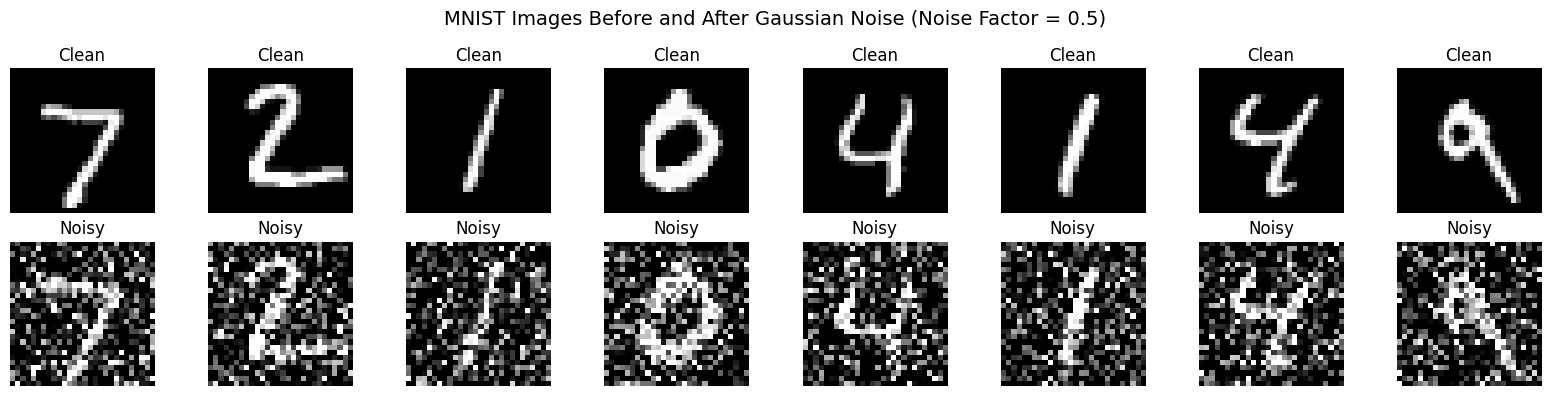


Visual sanity check completed successfully.


In [4]:
print("=" * 70)
print("VISUAL COMPARISON OF CLEAN AND NOISY MNIST IMAGES")
print("=" * 70)

def show_clean_noisy_pairs(clean_images, noisy_images, n=8):

    plt.figure(figsize=(16, 4))

    for i in range(n):


        # Clean Image


        ax = plt.subplot(2, n, i + 1)

        plt.imshow(
            clean_images[i].squeeze(),
            cmap="gray",
            vmin=0,
            vmax=1
        )

        plt.title("Clean")
        plt.axis("off")


        # Noisy Image

        ax = plt.subplot(2, n, i + 1 + n)

        plt.imshow(
            noisy_images[i].squeeze(),
            cmap="gray",
            vmin=0,
            vmax=1
        )

        plt.title("Noisy")
        plt.axis("off")

    plt.suptitle(
        f"MNIST Images Before and After Gaussian Noise (Noise Factor = {NOISE_FACTOR})",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


# Display test images
show_clean_noisy_pairs(
    x_test,
    x_test_noisy,
    n=8
)

print("\nVisual sanity check completed successfully.")

### Observation

The visual sanity check confirms that Gaussian noise with a noise factor of **0.5** has been successfully added to the MNIST images. The noisy images show noticeable pixel-level corruption while still preserving the main digit structures, creating a suitable denoising task.

This comparison provides a clear visual baseline for the experiment. The trained autoencoder models will be evaluated on their ability to remove the added noise while preserving the important structural features of the handwritten digits. An effective denoising model should produce reconstructed images that are much closer to the clean images than the noisy inputs, both visually and according to quantitative metrics such as **MSE, PSNR, and SSIM**.


# Step 5: Model 1 — Dense Autoencoder (Baseline)

The first model is a **Dense Autoencoder**, which serves as the baseline architecture for the image denoising experiment.

Each **28 × 28 × 1** MNIST image is flattened into a **784-dimensional vector** and passed through fully connected encoder layers. The encoder gradually compresses the noisy input into a compact **32-dimensional latent representation (bottleneck)**. The decoder then reconstructs the image back to its original 784-dimensional representation, which is reshaped into **28 × 28 × 1** format.

### Architecture Flow

**Noisy Image (28 × 28 × 1) → Flatten (784) → Encoder → 32-Dimensional Bottleneck → Decoder → Reconstructed Clean Image (28 × 28 × 1)**

The model is trained using noisy images as inputs and their corresponding clean images as reconstruction targets.

This architecture provides a straightforward baseline for evaluating whether more spatially aware architectures, such as the **Convolutional Autoencoder** and the **Advanced Skip-Connection Autoencoder**, can achieve better denoising performance.

Because the Dense Autoencoder operates on flattened image vectors, it does not explicitly preserve the two-dimensional spatial relationships between neighboring pixels. This limitation is expected to serve as an important point of comparison with the subsequent convolution-based models.


In [5]:
print("=" * 70)
print("BUILDING MODEL 1 — DENSE AUTOENCODER")
print("=" * 70)

# Model Configuration

LATENT_DIM = 32

print(f"Input Shape          : (28, 28, 1)")
print(f"Flattened Dimension  : 784")
print(f"Latent Dimension     : {LATENT_DIM}")
print(f"Output Activation    : Sigmoid")
print(f"Loss Function        : Binary Crossentropy")

# Dense Autoencoder Builder

def build_dense_autoencoder(latent_dim=LATENT_DIM):

    # Input: Noisy MNIST image
    inputs = keras.Input(
        shape=(28, 28, 1),
        name="noisy_input"
    )


    # Encoder

    x = layers.Flatten(
        name="flatten"
    )(inputs)

    x = layers.Dense(
        128,
        activation="relu",
        name="encoder_dense"
    )(x)

    encoded = layers.Dense(
        latent_dim,
        activation="relu",
        name="latent_bottleneck"
    )(x)


    # Decoder


    x = layers.Dense(
        128,
        activation="relu",
        name="decoder_dense"
    )(encoded)

    x = layers.Dense(
        784,
        activation="sigmoid",
        name="reconstruction"
    )(x)

    outputs = layers.Reshape(
        (28, 28, 1),
        name="reconstructed_image"
    )(x)


    # Create Model


    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="Dense_Autoencoder"
    )

    return model


# Build Model

dense_ae = build_dense_autoencoder()

# Compile Model

dense_ae.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy"
)


# Model Summary

print("\nDense Autoencoder Architecture:\n")

dense_ae.summary()

print("\nDense Autoencoder created and compiled successfully.")

BUILDING MODEL 1 — DENSE AUTOENCODER
Input Shape          : (28, 28, 1)
Flattened Dimension  : 784
Latent Dimension     : 32
Output Activation    : Sigmoid
Loss Function        : Binary Crossentropy

Dense Autoencoder Architecture:



Model: "Dense_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense (Dense)           │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_bottleneck (Dense)       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense (Dense)           │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_image (Reshape)   │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)


Dense Autoencoder created and compiled successfully.


### Observation

The Dense Autoencoder was successfully constructed with **209,968 trainable parameters**. The encoder converts each **28 × 28** grayscale image into a **784-dimensional** flattened vector and gradually compresses it into a compact **32-dimensional latent bottleneck**.

The decoder then reconstructs this compressed representation back to the original **28 × 28 × 1** image dimensions. A sigmoid activation function is used in the final reconstruction layer to produce pixel values within the normalized **[0, 1]** range.

This model serves as the baseline for the denoising experiment. Since it processes images as flattened vectors, it does not preserve the two-dimensional spatial relationships between neighboring pixels. Its performance will provide a useful reference for comparing the convolution-based autoencoder architectures.


# Step 6: Train the Dense Autoencoder

The Dense Autoencoder is trained using the **noisy MNIST training images as inputs** and the corresponding **clean MNIST images as reconstruction targets**.

The model is trained for a maximum of **100 epochs** with a batch size of **256**. To improve training efficiency and reduce overfitting, two callback strategies are used:

* **Early Stopping:** Monitors validation loss and automatically stops training when no improvement is observed for 10 consecutive epochs. The weights from the best-performing epoch are restored.
* **ReduceLROnPlateau:** Reduces the learning rate when validation loss stops improving, allowing the optimizer to make smaller and more precise updates as training progresses.

The fixed noisy test dataset is used for validation to monitor the model's ability to reconstruct clean images from unseen noisy inputs.

After training, the **best epoch and best validation loss** are recorded. Since the model is trained using Binary Cross-Entropy loss, additional evaluation metrics such as **MSE, PSNR, and SSIM** will later be computed separately to provide a consistent quantitative comparison across all autoencoder architectures.


In [6]:
print("=" * 70)
print("TRAINING MODEL 1 — DENSE AUTOENCODER")
print("=" * 70)

dense_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

dense_history = dense_ae.fit(
    x_train_noisy,
    x_train,
    epochs=100,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=dense_callbacks,
    verbose=2
)

best_epoch = np.argmin(dense_history.history["val_loss"]) + 1
best_val_loss = np.min(dense_history.history["val_loss"])

print("\n" + "=" * 70)
print("DENSE AUTOENCODER TRAINING COMPLETED")
print("=" * 70)

print(f"Epochs Completed      : {len(dense_history.history['loss'])}")
print(f"Best Epoch            : {best_epoch}")
print(f"Best Validation Loss  : {best_val_loss:.6f}")

TRAINING MODEL 1 — DENSE AUTOENCODER
Epoch 1/100
235/235 - 5s - 22ms/step - loss: 0.2587 - val_loss: 0.1929 - learning_rate: 0.0010
Epoch 2/100
235/235 - 1s - 6ms/step - loss: 0.1784 - val_loss: 0.1654 - learning_rate: 0.0010
Epoch 3/100
235/235 - 2s - 9ms/step - loss: 0.1583 - val_loss: 0.1515 - learning_rate: 0.0010
Epoch 4/100
235/235 - 1s - 3ms/step - loss: 0.1492 - val_loss: 0.1450 - learning_rate: 0.0010
Epoch 5/100
235/235 - 1s - 3ms/step - loss: 0.1432 - val_loss: 0.1398 - learning_rate: 0.0010
Epoch 6/100
235/235 - 1s - 3ms/step - loss: 0.1389 - val_loss: 0.1365 - learning_rate: 0.0010
Epoch 7/100
235/235 - 1s - 3ms/step - loss: 0.1361 - val_loss: 0.1343 - learning_rate: 0.0010
Epoch 8/100
235/235 - 1s - 5ms/step - loss: 0.1340 - val_loss: 0.1322 - learning_rate: 0.0010
Epoch 9/100
235/235 - 1s - 3ms/step - loss: 0.1322 - val_loss: 0.1306 - learning_rate: 0.0010
Epoch 10/100
235/235 - 1s - 3ms/step - loss: 0.1307 - val_loss: 0.1292 - learning_rate: 0.0010
Epoch 11/100
235/235 

### Observation

The Dense Autoencoder was successfully trained for the full **100 epochs**. The training process showed stable convergence, with the training loss decreasing from **0.2587** in the first epoch to approximately **0.1150**, while the validation loss improved from **0.1929** to a best value of **0.117195**.

The best validation performance was achieved at **Epoch 100**, indicating that the model continued to improve throughout the training period. The small difference between the final training and validation losses suggests that the model generalized well to unseen noisy test images without clear signs of severe overfitting.

Early Stopping was not triggered because the validation loss continued to improve, and the learning rate remained at its initial value of **0.001** throughout training.

Overall, the results show that the Dense Autoencoder successfully learned to reconstruct clean MNIST images from noisy inputs. However, the Binary Cross-Entropy training loss alone is not enough to assess denoising quality. Therefore, the reconstructed images will also be evaluated visually and quantitatively using **MSE, PSNR, and SSIM** for a fair comparison with the Convolutional and Advanced Skip-Connection Autoencoders.


# Step 7: Model 2 — Convolutional Autoencoder

The second model is a **Convolutional Autoencoder (CAE)** designed to take advantage of the two-dimensional spatial structure of MNIST images.

Unlike the Dense Autoencoder, which flattens each image into a one-dimensional vector, the Convolutional Autoencoder processes images directly in their original **28 × 28 × 1** format. This enables the network to learn spatial features such as edges, curves, strokes, and local pixel relationships that are essential for reconstructing handwritten digits.

### Architecture Approach

The **encoder** uses convolutional layers to extract meaningful spatial features and pooling operations to gradually reduce the spatial dimensions of the feature maps.

The **decoder** reconstructs the clean image by progressively increasing the spatial resolution using upsampling operations combined with convolutional layers.

### Architecture Flow

**Noisy Image → Convolutional Feature Extraction → Spatial Compression → Latent Feature Representation → Upsampling and Reconstruction → Clean Image**

By preserving spatial information throughout the network, the Convolutional Autoencoder is expected to reconstruct digit structures more effectively and remove noise more accurately than the Dense Autoencoder.

The model will be trained using the same fixed noisy training images as inputs and the corresponding clean images as targets. It will also be evaluated on the same fixed noisy test set used for the Dense Autoencoder, ensuring a consistent comparison of denoising performance using **MSE, PSNR, and SSIM**.


In [7]:
print("=" * 70)
print("BUILDING MODEL 2 — CONVOLUTIONAL AUTOENCODER")
print("=" * 70)

def build_conv_autoencoder():

    inputs = keras.Input(
        shape=(28, 28, 1),
        name="noisy_input"
    )

    # Encoder
    x = layers.Conv2D(
        32,
        kernel_size=3,
        activation="relu",
        padding="same",
        name="encoder_conv1"
    )(inputs)

    x = layers.MaxPooling2D(
        pool_size=2,
        padding="same",
        name="encoder_pool1"
    )(x)

    x = layers.Conv2D(
        32,
        kernel_size=3,
        activation="relu",
        padding="same",
        name="encoder_conv2"
    )(x)

    encoded = layers.MaxPooling2D(
        pool_size=2,
        padding="same",
        name="spatial_bottleneck"
    )(x)

    # Decoder
    x = layers.Conv2D(
        32,
        kernel_size=3,
        activation="relu",
        padding="same",
        name="decoder_conv1"
    )(encoded)

    x = layers.UpSampling2D(
        size=2,
        name="decoder_upsample1"
    )(x)

    x = layers.Conv2D(
        32,
        kernel_size=3,
        activation="relu",
        padding="same",
        name="decoder_conv2"
    )(x)

    x = layers.UpSampling2D(
        size=2,
        name="decoder_upsample2"
    )(x)

    outputs = layers.Conv2D(
        1,
        kernel_size=3,
        activation="sigmoid",
        padding="same",
        name="reconstructed_image"
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="Convolutional_Autoencoder"
    )

    return model


conv_ae = build_conv_autoencoder()

conv_ae.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy"
)

print("\nConvolutional Autoencoder Architecture:\n")

conv_ae.summary()

print("\nConvolutional Autoencoder created and compiled successfully.")

BUILDING MODEL 2 — CONVOLUTIONAL AUTOENCODER

Convolutional Autoencoder Architecture:



Model: "Convolutional_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv1 (Conv2D)          │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool1 (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv2 (Conv2D)          │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_bottleneck              │ (None, 7, 7, 32)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv1 (Conv2D)          │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsample1               │ (None, 14, 14, 32)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv2 (Conv2D)          │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsample2               │ (None, 28, 28, 32)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_image (Conv2D)    │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)


Convolutional Autoencoder created and compiled successfully.


### Observation

The Convolutional Autoencoder was successfully constructed with **28,353 trainable parameters**. The encoder gradually reduces the spatial dimensions of the input from **28 × 28** to a **7 × 7 × 32 spatial bottleneck**, while the convolutional layers learn local features such as digit edges, curves, and strokes.

The decoder then progressively restores the spatial resolution from **7 × 7** to **28 × 28**, producing a reconstructed single-channel image with pixel values constrained to the normalized **[0, 1]** range through the final sigmoid activation.

Notably, the Convolutional Autoencoder contains significantly fewer trainable parameters than the Dense Autoencoder (**28,353 vs. 209,968**). However, convolutional weight sharing and the preservation of two-dimensional spatial relationships allow it to learn image structures more efficiently. Its denoising performance will therefore be evaluated to determine whether spatial feature learning can provide better reconstruction quality despite the much smaller parameter count.


# Step 8: Train the Convolutional Autoencoder and Monitor Convergence

The Convolutional Autoencoder is trained using the same **fixed noisy MNIST training images as inputs** and their corresponding **clean images as reconstruction targets**.

To provide enough opportunity for convergence, the model is trained for a maximum number of epochs while callback mechanisms are used to manage the training process and prevent unnecessary overfitting.

The **training and validation loss curves** will be monitored to examine the model's learning behavior. In particular, the validation loss is observed for signs of convergence or plateauing. A steadily decreasing validation loss indicates continued improvement on unseen noisy images, while a flattening or increasing validation loss may suggest that further training offers limited generalization benefit.

**Early Stopping** and **ReduceLROnPlateau** will be used to automatically manage convergence and retain the best-performing model weights.

This checkpoint allows us to confirm that the Convolutional Autoencoder has converged appropriately before evaluating its denoising performance and comparing it with the Dense Autoencoder.


TRAINING MODEL 2 — CONVOLUTIONAL AUTOENCODER
Epoch 1/100
235/235 - 10s - 43ms/step - loss: 0.2002 - val_loss: 0.1247 - learning_rate: 0.0010
Epoch 2/100
235/235 - 2s - 10ms/step - loss: 0.1201 - val_loss: 0.1140 - learning_rate: 0.0010
Epoch 3/100
235/235 - 2s - 10ms/step - loss: 0.1123 - val_loss: 0.1094 - learning_rate: 0.0010
Epoch 4/100
235/235 - 2s - 10ms/step - loss: 0.1085 - val_loss: 0.1066 - learning_rate: 0.0010
Epoch 5/100
235/235 - 3s - 11ms/step - loss: 0.1062 - val_loss: 0.1050 - learning_rate: 0.0010
Epoch 6/100
235/235 - 2s - 10ms/step - loss: 0.1045 - val_loss: 0.1034 - learning_rate: 0.0010
Epoch 7/100
235/235 - 3s - 11ms/step - loss: 0.1032 - val_loss: 0.1018 - learning_rate: 0.0010
Epoch 8/100
235/235 - 2s - 10ms/step - loss: 0.1022 - val_loss: 0.1010 - learning_rate: 0.0010
Epoch 9/100
235/235 - 2s - 10ms/step - loss: 0.1014 - val_loss: 0.1003 - learning_rate: 0.0010
Epoch 10/100
235/235 - 2s - 10ms/step - loss: 0.1008 - val_loss: 0.0997 - learning_rate: 0.0010
Epo

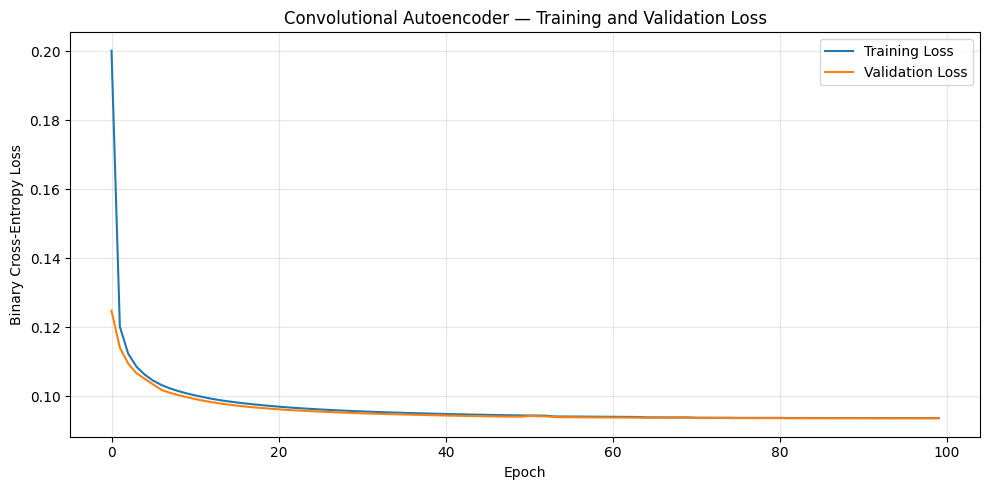

In [8]:
print("=" * 70)
print("TRAINING MODEL 2 — CONVOLUTIONAL AUTOENCODER")
print("=" * 70)

conv_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

conv_history = conv_ae.fit(
    x_train_noisy,
    x_train,
    epochs=100,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=conv_callbacks,
    verbose=2
)

best_conv_epoch = np.argmin(conv_history.history["val_loss"]) + 1
best_conv_val_loss = np.min(conv_history.history["val_loss"])

print("\n" + "=" * 70)
print("CONVOLUTIONAL AUTOENCODER TRAINING COMPLETED")
print("=" * 70)

print(f"Epochs Completed      : {len(conv_history.history['loss'])}")
print(f"Best Epoch            : {best_conv_epoch}")
print(f"Best Validation Loss  : {best_conv_val_loss:.6f}")

plt.figure(figsize=(10, 5))

plt.plot(
    conv_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    conv_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Convolutional Autoencoder — Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation

The Convolutional Autoencoder was successfully trained for **100 epochs** and showed stable convergence throughout the training process. The validation loss decreased from **0.1247** in the first epoch to a best value of **0.093551** at **Epoch 100**.

The training and validation loss curves remained closely aligned, indicating good generalization to unseen noisy test images without clear signs of severe overfitting. The model improved rapidly during the early epochs, followed by smaller improvements as training approached convergence.

The **ReduceLROnPlateau** callback successfully reduced the learning rate when the validation loss began to plateau. This allowed finer parameter updates during the later stages of training and contributed to continued improvements in validation performance.

Compared with the Dense Autoencoder, which achieved a best validation loss of **0.117195**, the Convolutional Autoencoder achieved a lower value of **0.093551**. This corresponds to an approximate **20.2% reduction in Binary Cross-Entropy validation loss**, highlighting the advantage of learning two-dimensional spatial features for image denoising.

Despite having only **28,353 trainable parameters**, compared with **209,968 parameters** in the Dense Autoencoder, the Convolutional Autoencoder achieved better validation performance. This suggests that convolutional layers provide a more parameter-efficient representation for the MNIST image denoising task.

Overall, the results indicate that convolution-based architectures are better suited for image reconstruction than fully connected architectures. The final comparison, however, will be based on the common quantitative metrics **MSE, PSNR, and SSIM**, together with visual inspection of the reconstructed images.


# Step 9: Visual Comparison — Original vs Noisy vs Reconstructed Images

Before introducing the advanced autoencoder architecture, the denoising performance of the two trained baseline models is visually compared.

For the same MNIST test samples, four versions of each image are displayed side by side:

**Clean Ground Truth → Noisy Input → Dense Autoencoder Reconstruction → Convolutional Autoencoder Reconstruction**

This checkpoint provides a qualitative assessment of how well each model removes Gaussian noise while preserving the underlying structure of the handwritten digits.

The **Dense Autoencoder** serves as the fully connected baseline, while the **Convolutional Autoencoder** is expected to produce cleaner and more structurally accurate reconstructions by taking advantage of spatial relationships between neighboring pixels.

All reconstructions are generated from the same fixed noisy test images, ensuring a fair visual comparison between the models. Quantitative evaluation using **MSE, PSNR, and SSIM** will later complement this visual analysis.


VISUAL COMPARISON — DENSE AE VS CONVOLUTIONAL AE


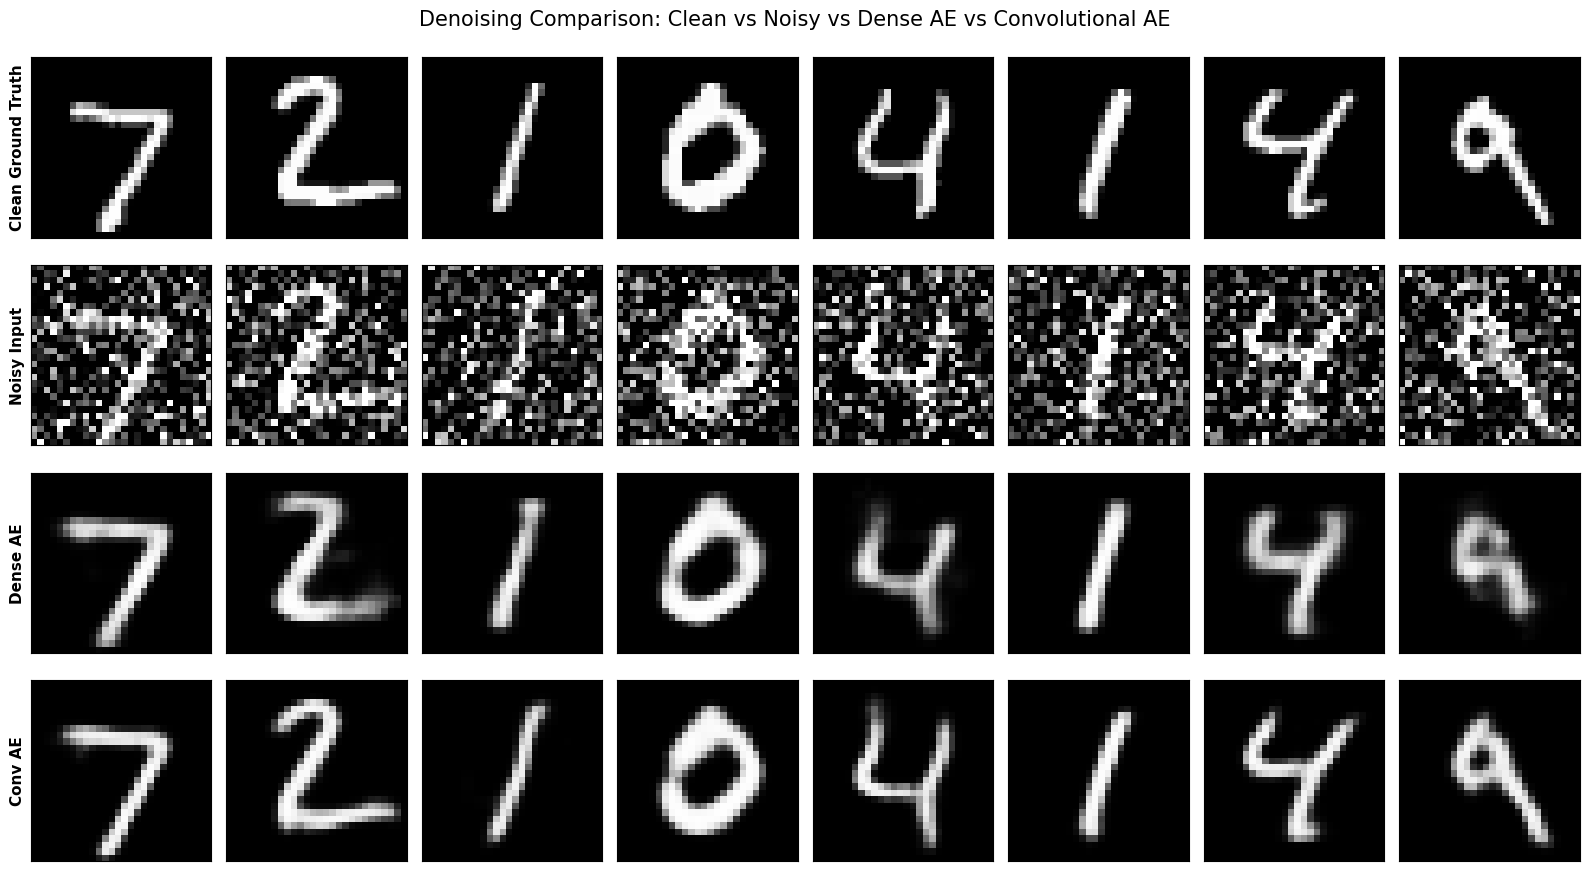


Visual denoising comparison completed successfully.


In [9]:
print("=" * 70)
print("VISUAL COMPARISON — DENSE AE VS CONVOLUTIONAL AE")
print("=" * 70)

# Generate denoised predictions on the same fixed noisy test set
dense_denoised = dense_ae.predict(
    x_test_noisy,
    verbose=0
)

conv_denoised = conv_ae.predict(
    x_test_noisy,
    verbose=0
)

n = 8

rows = [
    (x_test, "Clean Ground Truth"),
    (x_test_noisy, "Noisy Input"),
    (dense_denoised, "Dense AE"),
    (conv_denoised, "Conv AE")
]

plt.figure(figsize=(16, 9))

for row_index, (images, label) in enumerate(rows):

    for i in range(n):

        ax = plt.subplot(
            len(rows),
            n,
            row_index * n + i + 1
        )

        plt.imshow(
            images[i].squeeze(),
            cmap="gray",
            vmin=0,
            vmax=1
        )

        plt.xticks([])
        plt.yticks([])

        if i == 0:
            ax.set_ylabel(
                label,
                fontsize=11,
                fontweight="bold"
            )

plt.suptitle(
    "Denoising Comparison: Clean vs Noisy vs Dense AE vs Convolutional AE",
    fontsize=15
)

plt.tight_layout()
plt.show()

print("\nVisual denoising comparison completed successfully.")

### Observation

The qualitative comparison shows that both trained autoencoders successfully remove a substantial amount of Gaussian noise from the corrupted MNIST inputs and reconstruct recognizable handwritten digits.

The **Dense Autoencoder** effectively reduces most of the background noise, but its reconstructed images appear smoother and blurrier, with some fine stroke details being lost. The **Convolutional Autoencoder** produces sharper reconstructions with cleaner backgrounds and better preservation of the original digit structures, making its outputs more similar to the clean ground-truth images.

These visual results are consistent with the training outcomes, where the Convolutional Autoencoder achieved a lower Binary Cross-Entropy validation loss than the Dense Autoencoder. This indicates that preserving spatial information through convolutional operations is more effective for MNIST image denoising than processing flattened image vectors.

Overall, the comparison shows that the **Convolutional Autoencoder outperforms the Dense Autoencoder** in reconstruction quality. The final ranking of all models will be determined using both qualitative visual analysis and quantitative evaluation with **MSE, PSNR, and SSIM** on the same fixed noisy test dataset.


# Step 10: Model 3 — Advanced Skip-Connection Autoencoder

The third model is an **Advanced Skip-Connection Autoencoder**, designed to deliver better reconstruction quality than the Dense and standard Convolutional Autoencoders.

This architecture combines deeper convolutional feature extraction, **U-Net-style skip connections**, **Batch Normalization**, and a reconstruction objective focused on both perceptual and pixel-level image quality.

### 1. Skip Connections

A conventional encoder-decoder compresses the input through a lower-resolution bottleneck. Although this helps the network learn compact high-level representations, some fine spatial information can be lost during downsampling.

To overcome this limitation, skip connections transfer feature maps from encoder layers directly to the corresponding decoder layers. This enables high-resolution spatial information, such as digit edges and fine stroke details, to bypass the bottleneck and contribute directly to image reconstruction.

### 2. Batch Normalization

Batch Normalization is incorporated into the convolutional blocks to stabilize intermediate feature distributions during training. This helps improve optimization stability and supports efficient convergence of the deeper network.

### 3. Combined MSE and SSIM Loss

Unlike the baseline models trained using Binary Cross-Entropy, the advanced model uses a custom objective that combines:

* **Mean Squared Error (MSE):** Encourages pixel-level similarity between reconstructed and clean images. Lower MSE also corresponds to higher PSNR when the image intensity range is fixed.
* **Structural Similarity (SSIM) Loss:** Encourages the preservation of structural information such as local luminance, contrast, and spatial patterns.

The combined objective is designed to optimize both **pixel-level reconstruction accuracy** and **structural similarity**:

**Combined Loss = MSE + λ × (1 − SSIM)**

where **λ** controls the contribution of the structural similarity component.

### Architecture Strategy

**Noisy Input → Deep Convolutional Encoder → Bottleneck → Decoder with Skip Connections → Reconstructed Clean Image**

The advanced model is expected to preserve fine digit structures more effectively while reducing background noise. Its performance will be evaluated on the same fixed noisy test dataset using **MSE, PSNR, and SSIM**, ensuring that all three models are assessed under identical test conditions.

> **Experimental Note:** This model introduces improvements in both architecture and optimization objective. Therefore, its performance represents an enhanced denoising pipeline rather than a strict architecture-only comparison with the two baseline models.


In [10]:
print("=" * 70)
print("BUILDING MODEL 3 — ADVANCED SKIP-CONNECTION AUTOENCODER")
print("=" * 70)

def conv_block(x, filters, name):

    x = layers.Conv2D(
        filters,
        kernel_size=3,
        padding="same",
        use_bias=False,
        name=f"{name}_conv1"
    )(x)

    x = layers.BatchNormalization(
        name=f"{name}_bn1"
    )(x)

    x = layers.Activation(
        "relu",
        name=f"{name}_relu1"
    )(x)

    x = layers.Conv2D(
        filters,
        kernel_size=3,
        padding="same",
        use_bias=False,
        name=f"{name}_conv2"
    )(x)

    x = layers.BatchNormalization(
        name=f"{name}_bn2"
    )(x)

    x = layers.Activation(
        "relu",
        name=f"{name}_relu2"
    )(x)

    return x


def build_advanced_autoencoder():

    inputs = keras.Input(
        shape=(28, 28, 1),
        name="noisy_input"
    )

    # Encoder Block 1
    e1 = conv_block(
        inputs,
        filters=64,
        name="encoder_block1"
    )

    p1 = layers.MaxPooling2D(
        pool_size=2,
        name="encoder_pool1"
    )(e1)

    # Encoder Block 2
    e2 = conv_block(
        p1,
        filters=128,
        name="encoder_block2"
    )

    p2 = layers.MaxPooling2D(
        pool_size=2,
        name="encoder_pool2"
    )(e2)

    # Bottleneck
    b = conv_block(
        p2,
        filters=256,
        name="bottleneck"
    )

    # Decoder Block 2
    u2 = layers.UpSampling2D(
        size=2,
        interpolation="bilinear",
        name="decoder_upsample2"
    )(b)

    u2 = layers.Conv2D(
        128,
        kernel_size=3,
        padding="same",
        activation="relu",
        name="decoder_projection2"
    )(u2)

    u2 = layers.Concatenate(
        name="skip_connection2"
    )([u2, e2])

    d2 = conv_block(
        u2,
        filters=128,
        name="decoder_block2"
    )

    # Decoder Block 1
    u1 = layers.UpSampling2D(
        size=2,
        interpolation="bilinear",
        name="decoder_upsample1"
    )(d2)

    u1 = layers.Conv2D(
        64,
        kernel_size=3,
        padding="same",
        activation="relu",
        name="decoder_projection1"
    )(u1)

    u1 = layers.Concatenate(
        name="skip_connection1"
    )([u1, e1])

    d1 = conv_block(
        u1,
        filters=64,
        name="decoder_block1"
    )

    # Reconstruction Layer
    outputs = layers.Conv2D(
        filters=1,
        kernel_size=3,
        padding="same",
        activation="sigmoid",
        name="reconstructed_image"
    )(d1)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="Advanced_Skip_Connection_Autoencoder"
    )

    return model


def combined_loss(y_true, y_pred):

    mse_loss = tf.reduce_mean(
        tf.square(y_true - y_pred)
    )

    ssim_score = tf.reduce_mean(
        tf.image.ssim(
            y_true,
            y_pred,
            max_val=1.0
        )
    )

    ssim_loss = 1.0 - ssim_score

    return mse_loss + 0.1 * ssim_loss


adv_ae = build_advanced_autoencoder()

adv_ae.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=combined_loss
)

print("\nAdvanced Skip-Connection Autoencoder Architecture:\n")

adv_ae.summary()

print("\nAdvanced Skip-Connection Autoencoder created and compiled successfully.")

BUILDING MODEL 3 — ADVANCED SKIP-CONNECTION AUTOENCODER

Advanced Skip-Connection Autoencoder Architecture:



Model: "Advanced_Skip_Connection_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ noisy_input         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_con… │ (None, 28, 28,    │        576 │ noisy_input[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_bn1  │ (None, 28, 28,    │        256 │ encoder_block1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_rel… │ (None, 28, 28,    │          0 │ encoder_block1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_con… │ (None, 28, 28,    │     36,864 │ encoder_block1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_bn2  │ (None, 28, 28,    │        256 │ encoder_block1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_rel… │ (None, 28, 28,    │          0 │ encoder_block1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_pool1       │ (None, 14, 14,    │          0 │ encoder_block1_r… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_con… │ (None, 14, 14,    │     73,728 │ encoder_pool1[0]… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_bn1  │ (None, 14, 14,    │        512 │ encoder_block2_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_rel… │ (None, 14, 14,    │          0 │ encoder_block2_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_con… │ (None, 14, 14,    │    147,456 │ encoder_block2_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_bn2  │ (None, 14, 14,    │        512 │ encoder_block2_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_rel… │ (None, 14, 14,    │          0 │ encoder_block2_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_pool2       │ (None, 7, 7, 128) │          0 │ encoder_block2_r… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_conv1    │ (None, 7, 7, 256) │    294,912 │ encoder_pool2[0]… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_bn1      │ (None, 7, 7, 256) │      1,024 │ bottleneck_conv1

 Total params: 2,070,849 (7.90 MB)

 Trainable params: 2,068,289 (7.89 MB)

 Non-trainable params: 2,560 (10.00 KB)


Advanced Skip-Connection Autoencoder created and compiled successfully.


### Observation

The Advanced Skip-Connection Autoencoder was successfully constructed with **2,070,849 total parameters**, of which **2,068,289 are trainable** and **2,560 are non-trainable Batch Normalization parameters**.

The encoder gradually transforms the noisy **28 × 28 × 1** input into richer feature representations while reducing the spatial resolution to a **7 × 7 × 256 bottleneck**. The decoder then restores the original spatial resolution through progressive upsampling and convolutional feature refinement.

Two **U-Net-style skip connections** directly transfer high-resolution encoder features to the corresponding decoder stages at **14 × 14** and **28 × 28** resolutions. These connections help preserve fine spatial information, improving the reconstruction of digit edges and stroke details.

Batch Normalization is used throughout the convolutional blocks to support stable training of the deeper architecture. The final sigmoid reconstruction layer produces an output of **28 × 28 × 1**, matching the dimensions and normalized pixel range of the clean MNIST target images.

Compared with the Dense and standard Convolutional Autoencoders, this architecture has greater representational capacity and incorporates multi-scale feature transfer through skip connections. Its effectiveness will be evaluated using the same fixed noisy test dataset and the quantitative metrics **MSE, PSNR, and SSIM**, together with qualitative visual comparison.

The model architecture was successfully created and compiled using the combined **MSE + SSIM reconstruction objective** and is ready for training.


# Step 11: Train the Advanced Autoencoder with Dynamic Noise Augmentation

The Advanced Skip-Connection Autoencoder is trained using a more robust training pipeline designed to improve generalization across different noise realizations.

### On-the-Fly Noise Augmentation

Unlike the Dense and Convolutional Autoencoders, which were trained using a single fixed noisy version of the MNIST training dataset, the advanced model uses **on-the-fly Gaussian noise augmentation**.

Fresh random noise is generated dynamically during training, exposing the model to different corrupted versions of the clean MNIST images throughout the training process. This reduces reliance on a single fixed noise realization and encourages the network to learn a more general mapping from noisy inputs to clean images.

The fixed `x_test_noisy` dataset is retained for validation and final evaluation, ensuring that validation remains deterministic and that all three models can ultimately be compared using exactly the same test inputs.

### Learning Rate Scheduling

`ReduceLROnPlateau` monitors the validation loss and gradually reduces the learning rate when improvement begins to level off. This allows larger parameter updates during the early stages of training and increasingly finer optimization as the model approaches convergence.

### Early Stopping

The model is given a generous maximum training budget of **100 epochs**. `EarlyStopping` continuously monitors validation loss and stops training when meaningful improvement is no longer observed for a specified number of epochs.

With `restore_best_weights=True`, the model automatically returns to the weights associated with the best observed validation loss rather than retaining the weights from the final training epoch.

### Best-Model Checkpointing

A `ModelCheckpoint` callback is used to save the best-performing model weights based on validation loss. This provides a persistent copy of the strongest checkpoint obtained during training for later evaluation and reproducibility.

This training strategy combines **dynamic noise augmentation, adaptive learning-rate reduction, early stopping, and best-model checkpointing** to give the advanced architecture sufficient opportunity to converge while limiting unnecessary training and overfitting.

> **Evaluation Protocol:** Although the advanced model is trained with dynamically generated noise, its final performance will be measured on the same fixed `x_test_noisy → x_test` evaluation pair used for the baseline models. The final model comparison will use identical **MSE, PSNR, and SSIM** calculations for all three architectures.


TRAINING MODEL 3 — ADVANCED SKIP-CONNECTION AUTOENCODER
Maximum Epochs          : 100
Batch Size              : 256
Noise Factor            : 0.5
Training Noise          : Dynamic Gaussian Noise
Validation Noise        : Fixed Gaussian Noise
Early Stopping Patience : 10
LR Reduction Patience   : 4
Epoch 1/100

Epoch 1: val_loss improved from None to 0.14546, saving model to best_advanced_autoencoder.weights.h5

Epoch 1: finished saving model to best_advanced_autoencoder.weights.h5
235/235 - 83s - 353ms/step - loss: 0.0279 - val_loss: 0.1455 - learning_rate: 0.0010
Epoch 2/100

Epoch 2: val_loss improved from 0.14546 to 0.03490, saving model to best_advanced_autoencoder.weights.h5

Epoch 2: finished saving model to best_advanced_autoencoder.weights.h5
235/235 - 43s - 184ms/step - loss: 0.0200 - val_loss: 0.0349 - learning_rate: 0.0010
Epoch 3/100

Epoch 3: val_loss improved from 0.03490 to 0.01950, saving model to best_advanced_autoencoder.weights.h5

Epoch 3: finished saving model to b

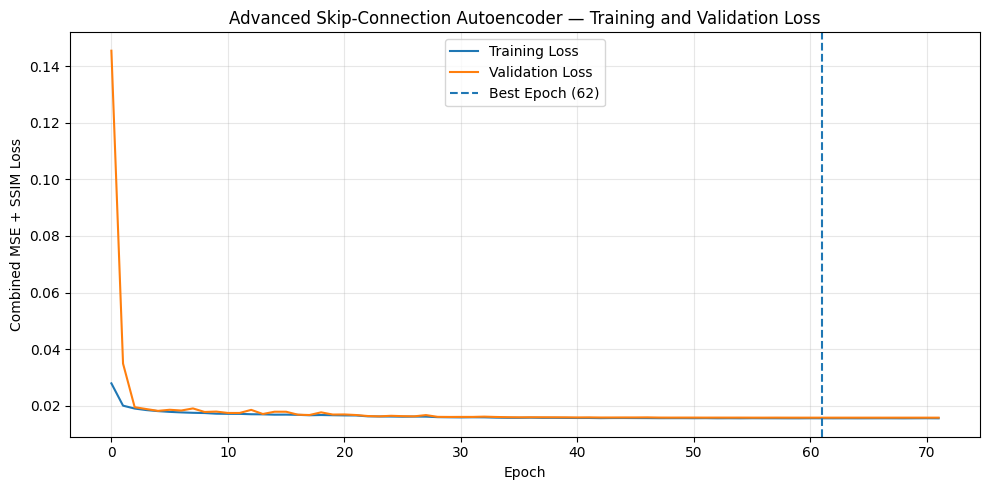


Training curve saved successfully.


In [11]:
print("=" * 70)
print("TRAINING MODEL 3 — ADVANCED SKIP-CONNECTION AUTOENCODER")
print("=" * 70)

BATCH_SIZE = 256
MAX_EPOCHS = 100

def make_noisy_dataset(
    clean_images,
    batch_size=BATCH_SIZE,
    noise_factor=NOISE_FACTOR,
    shuffle=True
):

    ds = tf.data.Dataset.from_tensor_slices(clean_images)

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(clean_images),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.batch(
        batch_size,
        drop_remainder=False
    )

    def add_noise_batch(clean_batch):

        noise = tf.random.normal(
            shape=tf.shape(clean_batch),
            mean=0.0,
            stddev=noise_factor,
            dtype=clean_batch.dtype
        )

        noisy_batch = clean_batch + noise

        noisy_batch = tf.clip_by_value(
            noisy_batch,
            0.0,
            1.0
        )

        return noisy_batch, clean_batch

    ds = ds.map(
        add_noise_batch,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.prefetch(
        tf.data.AUTOTUNE
    )

    return ds


train_ds = make_noisy_dataset(
    x_train,
    batch_size=BATCH_SIZE,
    noise_factor=NOISE_FACTOR,
    shuffle=True
)

checkpoint_path = "best_advanced_autoencoder.weights.h5"

adv_callbacks = [

    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

print(f"Maximum Epochs          : {MAX_EPOCHS}")
print(f"Batch Size              : {BATCH_SIZE}")
print(f"Noise Factor            : {NOISE_FACTOR}")
print("Training Noise          : Dynamic Gaussian Noise")
print("Validation Noise        : Fixed Gaussian Noise")
print("Early Stopping Patience : 10")
print("LR Reduction Patience   : 4")

adv_history = adv_ae.fit(
    train_ds,
    epochs=MAX_EPOCHS,
    validation_data=(
        x_test_noisy,
        x_test
    ),
    callbacks=adv_callbacks,
    verbose=2
)

best_adv_epoch = (
    int(np.argmin(adv_history.history["val_loss"])) + 1
)

best_adv_val_loss = np.min(
    adv_history.history["val_loss"]
)

print("\n" + "=" * 70)
print("ADVANCED AUTOENCODER TRAINING COMPLETED")
print("=" * 70)

print(
    f"Epochs Completed      : "
    f"{len(adv_history.history['loss'])}"
)

print(
    f"Best Epoch            : "
    f"{best_adv_epoch}"
)

print(
    f"Best Validation Loss  : "
    f"{best_adv_val_loss:.6f}"
)

print(
    f"Best Weights Saved    : "
    f"{checkpoint_path}"
)

plt.figure(figsize=(10, 5))

plt.plot(
    adv_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    adv_history.history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    x=best_adv_epoch - 1,
    linestyle="--",
    label=f"Best Epoch ({best_adv_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Combined MSE + SSIM Loss")

plt.title(
    "Advanced Skip-Connection Autoencoder — Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "advanced_autoencoder_training_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nTraining curve saved successfully.")

### Observation

The Advanced Skip-Connection Autoencoder successfully converged during training. The model completed 72 out of the maximum 100 epochs, with EarlyStopping automatically terminating training after validation performance stopped improving. The best validation performance was achieved at epoch 62 with a combined MSE + SSIM loss of 0.015795, and the corresponding model weights were automatically restored.

The training and validation loss curves show rapid convergence during the initial epochs followed by gradual stabilization. The small gap between the training and validation curves indicates good generalization without significant overfitting. Dynamic Gaussian noise augmentation exposed the model to continuously varying noisy inputs during training, while the fixed noisy validation set provided a consistent evaluation benchmark.

ReduceLROnPlateau progressively decreased the learning rate as validation improvement slowed, allowing increasingly fine parameter updates near convergence. Overall, the stable convergence, low validation loss, adaptive learning-rate scheduling, and successful restoration of the best-performing weights indicate that the advanced autoencoder was trained effectively.

The combined loss value should not be directly compared with the Binary Cross-Entropy losses of the Dense and Convolutional Autoencoders because different objective functions were used. A fair final comparison will therefore evaluate all three trained models on the identical test set using common quantitative metrics: MSE, PSNR, and SSIM.

## Step 12. Final Quantitative Evaluation — MSE, PSNR & SSIM Leaderboard

All three trained autoencoders are now evaluated on the **same fixed noisy MNIST test set** (`x_test_noisy`) against the corresponding clean ground-truth images (`x_test`).

To ensure a fair model-to-model comparison, the same evaluation metrics are calculated for every architecture:

* **MSE (Mean Squared Error) ↓** — measures pixel-level reconstruction error. Lower is better.
* **PSNR (Peak Signal-to-Noise Ratio) ↑** — measures reconstruction quality relative to image distortion. Higher is better.
* **SSIM (Structural Similarity Index) ↑** — measures structural and perceptual similarity between the reconstructed and original images. Higher is better.

Unlike the models' training losses, which cannot be directly compared because different loss functions were used, these common evaluation metrics provide a consistent benchmark for all three architectures.

The final leaderboard therefore identifies the best denoising model based on measured reconstruction performance rather than architectural assumptions or visual inspection alone.


In [12]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import pandas as pd
import numpy as np

print("=" * 80)
print("FINAL DENOISING PERFORMANCE — MODEL LEADERBOARD")
print("=" * 80)

# Generate predictions using all trained models
# All models are evaluated on exactly the same fixed noisy test images

dense_denoised = dense_ae.predict(
    x_test_noisy,
    verbose=0
)

conv_denoised = conv_ae.predict(
    x_test_noisy,
    verbose=0
)

adv_denoised = adv_ae.predict(
    x_test_noisy,
    verbose=0
)


def evaluate_model(clean, predicted, model_name):

    # Ensure predictions remain within the valid normalized image range
    predicted = np.clip(
        predicted,
        0.0,
        1.0
    )

    # Mean Squared Error
    mse_value = np.mean(
        (clean - predicted) ** 2
    )

    # PSNR calculated independently for every test image
    psnr_values = [
        psnr(
            clean[i].squeeze(),
            predicted[i].squeeze(),
            data_range=1.0
        )
        for i in range(len(clean))
    ]

    # SSIM calculated independently for every test image
    ssim_values = [
        ssim(
            clean[i].squeeze(),
            predicted[i].squeeze(),
            data_range=1.0
        )
        for i in range(len(clean))
    ]

    return {
        "Model": model_name,
        "MSE": mse_value,
        "PSNR (dB)": np.mean(psnr_values),
        "SSIM": np.mean(ssim_values)
    }


# Evaluate noisy input as the baseline
leaderboard = [

    evaluate_model(
        x_test,
        x_test_noisy,
        "No Denoising"
    ),

    evaluate_model(
        x_test,
        dense_denoised,
        "Dense Autoencoder"
    ),

    evaluate_model(
        x_test,
        conv_denoised,
        "Convolutional Autoencoder"
    ),

    evaluate_model(
        x_test,
        adv_denoised,
        "Advanced Skip-Connection Autoencoder"
    )

]


# Convert results into DataFrame

leaderboard_df = pd.DataFrame(
    leaderboard
)


# Rank models by PSNR
# Higher PSNR indicates better reconstruction quality

leaderboard_df["Rank"] = (
    leaderboard_df["PSNR (dB)"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)


# Reorder columns

leaderboard_df = leaderboard_df[
    [
        "Rank",
        "Model",
        "MSE",
        "PSNR (dB)",
        "SSIM"
    ]
]


# Sort leaderboard by rank

leaderboard_df = leaderboard_df.sort_values(
    by="Rank"
).reset_index(
    drop=True
)


print("\nMODEL PERFORMANCE LEADERBOARD")
print("-" * 80)

print(
    leaderboard_df.to_string(
        index=False,
        formatters={
            "MSE": "{:.6f}".format,
            "PSNR (dB)": "{:.2f}".format,
            "SSIM": "{:.4f}".format
        }
    )
)


# Determine best trained model
# Exclude the No Denoising baseline

trained_models_df = leaderboard_df[
    leaderboard_df["Model"] != "No Denoising"
]

best_model = trained_models_df.sort_values(
    by=["PSNR (dB)", "SSIM"],
    ascending=[False, False]
).iloc[0]


print("\n" + "=" * 80)
print("BEST PERFORMING DENOISING MODEL")
print("=" * 80)

print(
    f"Model      : {best_model['Model']}"
)

print(
    f"MSE        : {best_model['MSE']:.6f}"
)

print(
    f"PSNR       : {best_model['PSNR (dB)']:.2f} dB"
)

print(
    f"SSIM       : {best_model['SSIM']:.4f}"
)


# Save leaderboard

leaderboard_df.to_csv(
    "autoencoder_denoising_leaderboard.csv",
    index=False
)

print(
    "\nLeaderboard saved as "
    "'autoencoder_denoising_leaderboard.csv'"
)

print("\nFinal quantitative evaluation completed successfully.")

FINAL DENOISING PERFORMANCE — MODEL LEADERBOARD

MODEL PERFORMANCE LEADERBOARD
--------------------------------------------------------------------------------
 Rank                                Model      MSE PSNR (dB)   SSIM
    1 Advanced Skip-Connection Autoencoder 0.007103     21.90 0.9148
    2            Convolutional Autoencoder 0.010253     20.24 0.8746
    3                    Dense Autoencoder 0.017933     17.90 0.7893
    4                         No Denoising 0.115787      9.37 0.3747

BEST PERFORMING DENOISING MODEL
Model      : Advanced Skip-Connection Autoencoder
MSE        : 0.007103
PSNR       : 21.90 dB
SSIM       : 0.9148

Leaderboard saved as 'autoencoder_denoising_leaderboard.csv'

Final quantitative evaluation completed successfully.


### Observation

The final quantitative evaluation shows a clear and consistent improvement in denoising performance across the three autoencoder architectures.

The unprocessed noisy images produced an MSE of **0.115787**, a PSNR of **9.37 dB**, and an SSIM of **0.3747**, providing the baseline level of degradation caused by Gaussian noise.

The **Dense Autoencoder** significantly improved reconstruction quality, reducing MSE to **0.017933** while increasing PSNR to **17.90 dB** and SSIM to **0.7893**. The **Convolutional Autoencoder** achieved even better results, with an MSE of **0.010253**, PSNR of **20.24 dB**, and SSIM of **0.8746**, highlighting the benefit of preserving spatial information through convolutional layers.

The **Advanced Skip-Connection Autoencoder** delivered the best performance across all three metrics, achieving the lowest MSE of **0.007103**, the highest PSNR of **21.90 dB**, and the highest SSIM of **0.9148**.

The final performance ranking is:

**Advanced Skip-Connection Autoencoder > Convolutional Autoencoder > Dense Autoencoder > No Denoising**

Overall, the results confirm that the **Advanced Skip-Connection Autoencoder** is the best-performing model in this experiment, providing the highest reconstruction quality across all quantitative evaluation metrics.


## Step 13. Bonus Experiment — Ensemble of Convolutional and Advanced Autoencoders

As an additional experiment, the predictions of the **Convolutional Autoencoder** and the **Advanced Skip-Connection Autoencoder** are combined using simple pixel-wise averaging.

The two models use different architectures and may capture different reconstruction patterns. By averaging their predicted pixel intensities, the ensemble may reduce some model-specific reconstruction errors and produce a more balanced denoised output.

The ensemble reconstruction is calculated as:

**Ensemble Output = (Conv AE Output + Advanced AE Output) / 2**

This approach requires no additional model training and offers a simple way to investigate whether combining predictions from two independently trained denoising architectures can improve reconstruction quality.

The ensemble is evaluated on the same fixed noisy MNIST test set using **MSE, PSNR, and SSIM**. Its performance is compared directly with the Advanced Skip-Connection Autoencoder to determine experimentally whether ensembling provides any measurable improvement.

> **Note:** The ensemble is treated as a bonus experiment rather than one of the three primary autoencoder architectures. It will only be considered an improvement if the quantitative evaluation demonstrates superior performance.


In [13]:
print("=" * 70)
print("BONUS EXPERIMENT — ENSEMBLE DENOISING")
print("=" * 70)

# Equal-weight pixel-wise ensemble
ensemble_denoised = (
    conv_denoised + adv_denoised
) / 2.0

# Keep predictions within valid image range
ensemble_denoised = np.clip(
    ensemble_denoised,
    0.0,
    1.0
)

# Calculate MSE
ensemble_mse = np.mean(
    (x_test - ensemble_denoised) ** 2
)

# Calculate mean PSNR
ensemble_psnr = np.mean([
    psnr(
        x_test[i].squeeze(),
        ensemble_denoised[i].squeeze(),
        data_range=1.0
    )
    for i in range(len(x_test))
])

# Calculate mean SSIM
ensemble_ssim = np.mean([
    ssim(
        x_test[i].squeeze(),
        ensemble_denoised[i].squeeze(),
        data_range=1.0
    )
    for i in range(len(x_test))
])

print("\nENSEMBLE PERFORMANCE")
print("-" * 50)

print(f"MSE        : {ensemble_mse:.6f}")
print(f"PSNR       : {ensemble_psnr:.2f} dB")
print(f"SSIM       : {ensemble_ssim:.4f}")

print("\nADVANCED AE PERFORMANCE")
print("-" * 50)

print("MSE        : 0.007103")
print("PSNR       : 21.90 dB")
print("SSIM       : 0.9148")

print("\nEnsemble evaluation completed successfully.")

BONUS EXPERIMENT — ENSEMBLE DENOISING

ENSEMBLE PERFORMANCE
--------------------------------------------------
MSE        : 0.007788
PSNR       : 21.44 dB
SSIM       : 0.9012

ADVANCED AE PERFORMANCE
--------------------------------------------------
MSE        : 0.007103
PSNR       : 21.90 dB
SSIM       : 0.9148

Ensemble evaluation completed successfully.


### Bonus Experiment Observation

The equal-weight ensemble of the Convolutional Autoencoder and Advanced Skip-Connection Autoencoder achieved an MSE of **0.007788**, a PSNR of **21.44 dB**, and an SSIM of **0.9012**.

Although the ensemble performed better than the individual Convolutional and Dense Autoencoders, it did not surpass the Advanced Skip-Connection Autoencoder, which achieved a lower MSE of **0.007103**, a higher PSNR of **21.90 dB**, and a higher SSIM of **0.9148**.

This shows that simple prediction averaging does not always improve reconstruction quality. Because the Advanced Autoencoder already produces stronger reconstructions than the Convolutional Autoencoder, averaging the two predictions introduces errors from the weaker model and slightly reduces overall performance.

Therefore, the **Advanced Skip-Connection Autoencoder remains the best-performing denoising approach in this experiment across all three quantitative metrics**.

The ensemble experiment also highlights that combining multiple models is only beneficial when their predictions complement each other well enough to outperform the strongest individual model. In this case, equal-weight averaging did not provide such an improvement.

For methodological rigor, no ensemble weights were tuned using the final test set. The reported ensemble therefore represents a simple, predefined 50/50 averaging experiment rather than a test-set-optimized combination.


### Step 14 — Full Denoising Progression: From Noisy Input to Best Model

The complete denoising progression is visualized using the same MNIST test samples across all three trained autoencoder architectures.

Each column represents the same test image, while the rows show the progressive reconstruction stages:

**Clean Ground Truth → Noisy Input → Dense Autoencoder → Convolutional Autoencoder → Advanced Skip-Connection Autoencoder**

This comparison provides a direct qualitative view of how reconstruction quality improves as the model architecture becomes more effective for spatial image denoising.

The **Dense Autoencoder** provides the initial denoising baseline, the **Convolutional Autoencoder** improves spatial feature preservation and reconstruction sharpness, and the **Advanced Skip-Connection Autoencoder** represents the best-performing model based on the final quantitative evaluation.

The visual results should be interpreted together with the common test-set metrics:

* **Dense Autoencoder:** MSE = 0.017933, PSNR = 17.90 dB, SSIM = 0.7893
* **Convolutional Autoencoder:** MSE = 0.010253, PSNR = 20.24 dB, SSIM = 0.8746
* **Advanced Skip-Connection Autoencoder:** MSE = 0.007103, PSNR = 21.90 dB, SSIM = 0.9148

The final visualization therefore complements the quantitative leaderboard by showing whether the improvements measured through MSE, PSNR, and SSIM are also reflected in the perceptual quality and structural fidelity of the reconstructed handwritten digits.


CHECKPOINT 4 — FULL DENOISING PROGRESSION


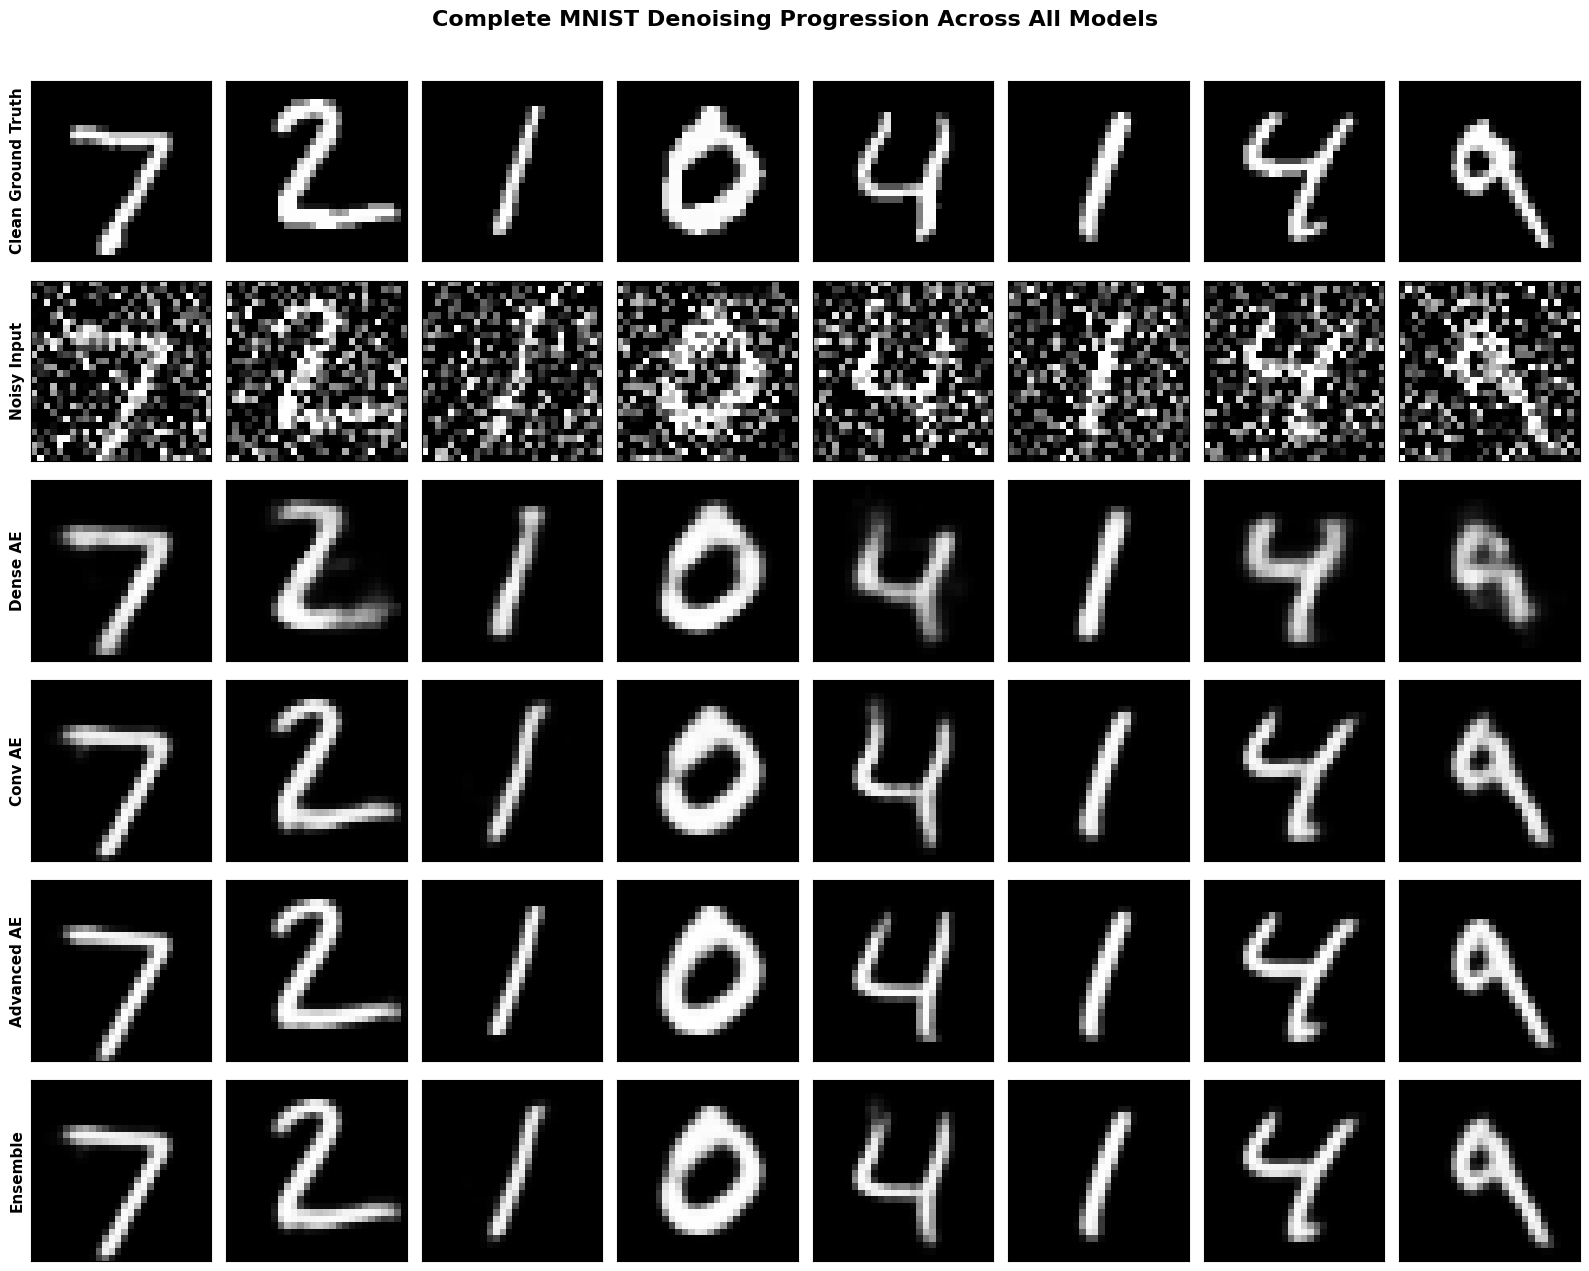


Full denoising progression visualization completed successfully.
Figure saved as 'complete_denoising_progression.png'


In [14]:
print("=" * 80)
print("CHECKPOINT 4 — FULL DENOISING PROGRESSION")
print("=" * 80)

n = 8

rows = [
    (x_test, "Clean Ground Truth"),
    (x_test_noisy, "Noisy Input"),
    (dense_denoised, "Dense AE"),
    (conv_denoised, "Conv AE"),
    (adv_denoised, "Advanced AE"),
    (ensemble_denoised, "Ensemble")
]

plt.figure(figsize=(16, 13))

for row_index, (images, label) in enumerate(rows):

    for i in range(n):

        ax = plt.subplot(
            len(rows),
            n,
            row_index * n + i + 1
        )

        plt.imshow(
            images[i].squeeze(),
            cmap="gray",
            vmin=0,
            vmax=1
        )

        plt.xticks([])
        plt.yticks([])

        if i == 0:
            ax.set_ylabel(
                label,
                fontsize=11,
                fontweight="bold"
            )

plt.suptitle(
    "Complete MNIST Denoising Progression Across All Models",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.97]
)

plt.savefig(
    "complete_denoising_progression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFull denoising progression visualization completed successfully.")
print("Figure saved as 'complete_denoising_progression.png'")

### Observation

The visual comparison shows a clear improvement in denoising quality across the developed autoencoder architectures.

The **Noisy Input** images are heavily corrupted by Gaussian noise, making some digit structures difficult to recognize. Even so, all three autoencoders successfully reconstruct recognizable handwritten digits.

The **Dense Autoencoder** removes much of the background noise but produces smoother and blurrier reconstructions. The **Convolutional Autoencoder** preserves spatial information more effectively, resulting in cleaner backgrounds and sharper digit structures.

The **Advanced Skip-Connection Autoencoder** delivers the best overall reconstruction quality, producing clearer digits with well-preserved structures that closely match the original images. This is consistent with its superior quantitative results, achieving the lowest MSE (**0.007103**), highest PSNR (**21.90 dB**), and highest SSIM (**0.9148**).

Although the **Ensemble** also generates good reconstructions, its quantitative performance is slightly lower than the Advanced Autoencoder. Overall, both the visual and quantitative results confirm the **Advanced Skip-Connection Autoencoder** as the best-performing denoising model in this experiment.


## Step 15. Bonus Experiment — Robustness Across Different Noise Levels

The Advanced Skip-Connection Autoencoder was trained using **on-the-fly Gaussian noise augmentation** with a fixed noise factor of `0.5`. Although fresh random noise was generated dynamically throughout training, the magnitude of the injected noise remained centered around the same configured noise level.

This bonus experiment examines whether the trained model can generalize to **different noise intensities that were not explicitly used during training**.

The Advanced Autoencoder is tested at multiple Gaussian noise factors, ranging from relatively mild corruption to noise levels that are more severe than the training condition.

For each noise level, reconstruction performance is evaluated using the same quantitative metrics:

* **MSE ↓** — lower values indicate smaller pixel-level reconstruction error.
* **PSNR ↑** — higher values indicate better reconstruction quality.
* **SSIM ↑** — higher values indicate stronger preservation of structural information.

This experiment provides an additional robustness analysis beyond the primary fixed-noise benchmark. A model that maintains strong denoising performance across varying noise intensities demonstrates greater robustness to changes in input corruption severity.

> **Experimental Note:** The model was trained with dynamically generated Gaussian noise at a fixed noise factor of `0.5`. Therefore, this experiment evaluates generalization across different Gaussian noise magnitudes rather than across entirely different noise distributions or noise types.


BONUS EXPERIMENT — ROBUSTNESS ACROSS DIFFERENT NOISE LEVELS


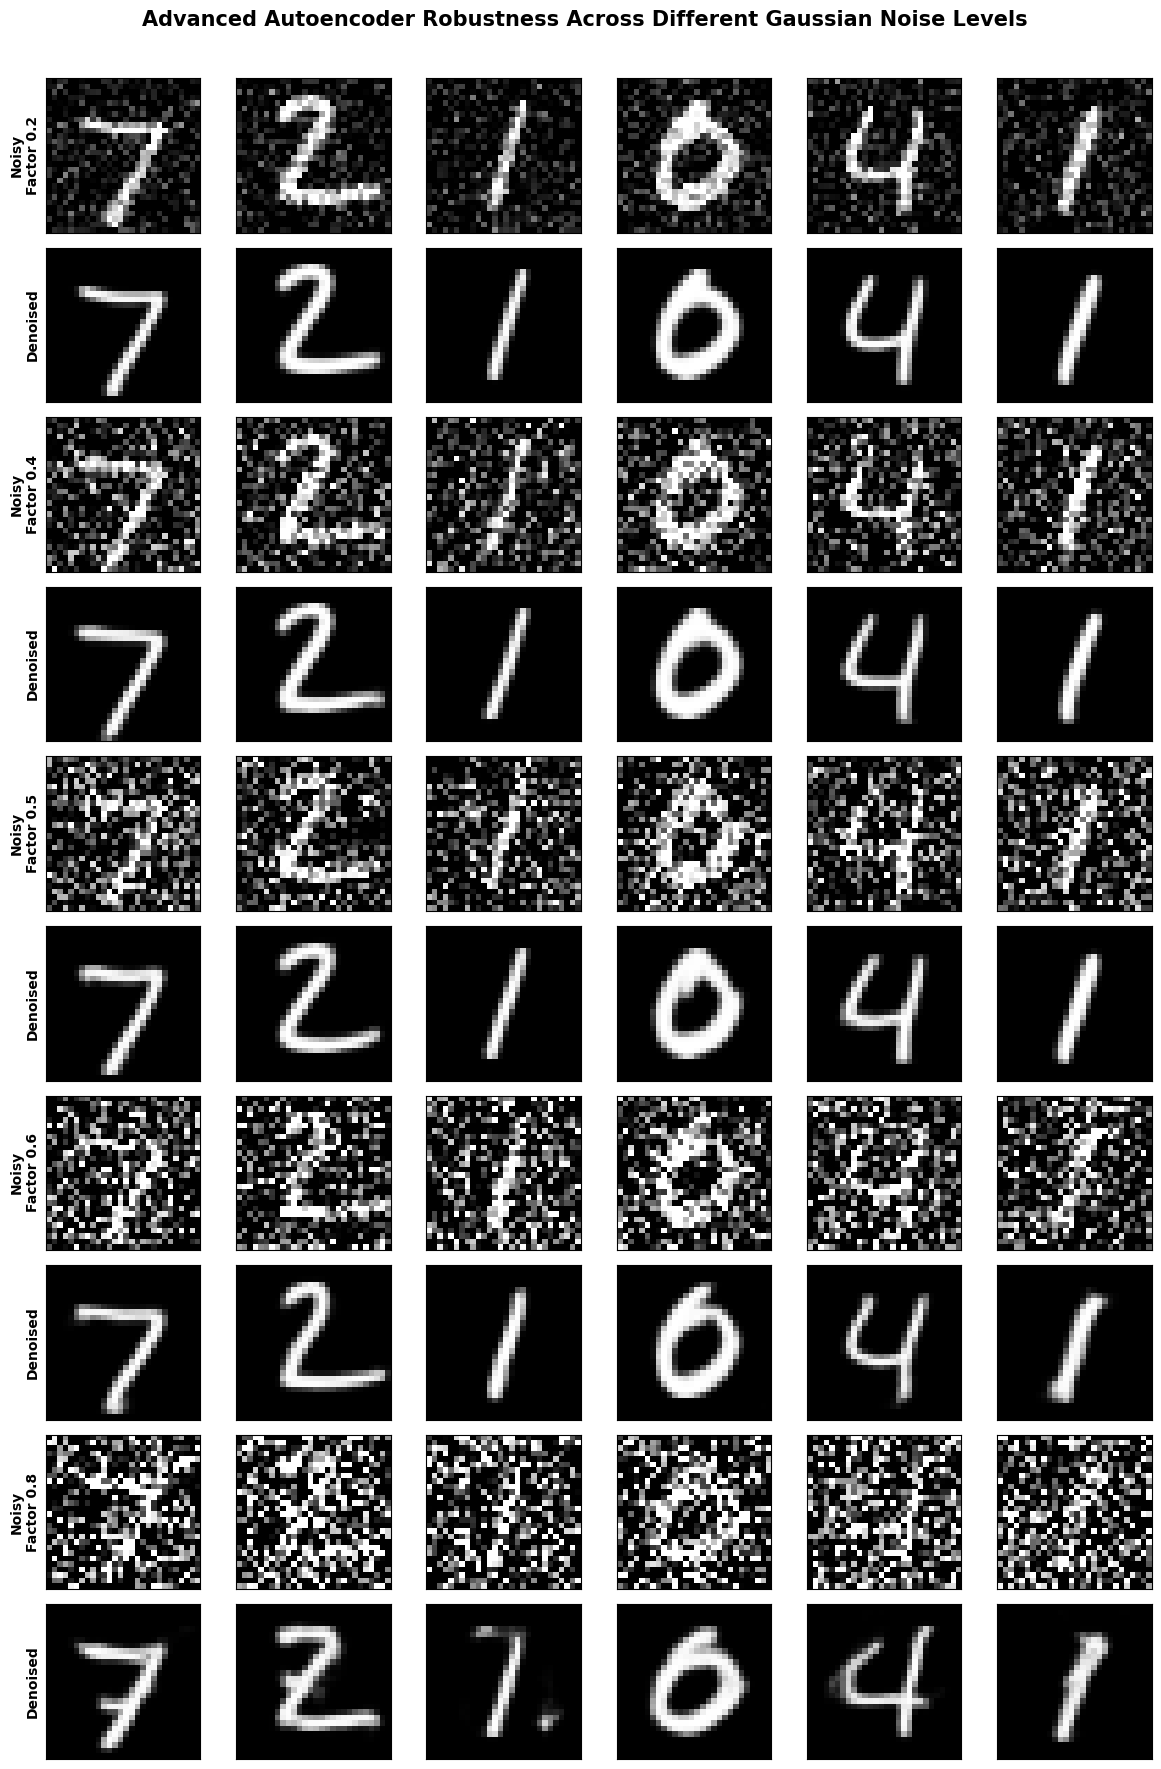


Noise levels evaluated: [0.2, 0.4, 0.5, 0.6, 0.8]
Robustness visualization completed successfully.
Figure saved as 'advanced_autoencoder_noise_robustness.png'


In [15]:
print("=" * 80)
print("BONUS EXPERIMENT — ROBUSTNESS ACROSS DIFFERENT NOISE LEVELS")
print("=" * 80)

noise_levels = [0.2, 0.4, 0.5, 0.6, 0.8]
sample = x_test[:6]

fig, axes = plt.subplots(
    len(noise_levels) * 2,
    6,
    figsize=(12, 18)
)

for row, noise_factor in enumerate(noise_levels):

    # Generate reproducible noisy samples
    noisy_sample = add_noise(
        sample,
        factor=noise_factor,
        seed=SEED + row
    )

    # Denoise using the trained Advanced Autoencoder
    denoised_sample = adv_ae.predict(
        noisy_sample,
        verbose=0
    )

    for col in range(6):

        # Noisy input
        axes[row * 2, col].imshow(
            noisy_sample[col].squeeze(),
            cmap="gray",
            vmin=0,
            vmax=1
        )

        axes[row * 2, col].set_xticks([])
        axes[row * 2, col].set_yticks([])

        # Denoised output
        axes[row * 2 + 1, col].imshow(
            denoised_sample[col].squeeze(),
            cmap="gray",
            vmin=0,
            vmax=1
        )

        axes[row * 2 + 1, col].set_xticks([])
        axes[row * 2 + 1, col].set_yticks([])

        if col == 0:

            axes[row * 2, col].set_ylabel(
                f"Noisy\nFactor {noise_factor}",
                fontsize=10,
                fontweight="bold"
            )

            axes[row * 2 + 1, col].set_ylabel(
                "Denoised",
                fontsize=10,
                fontweight="bold"
            )

plt.suptitle(
    "Advanced Autoencoder Robustness Across Different Gaussian Noise Levels",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.97]
)

plt.savefig(
    "advanced_autoencoder_noise_robustness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nNoise levels evaluated:", noise_levels)
print("Robustness visualization completed successfully.")
print("Figure saved as 'advanced_autoencoder_noise_robustness.png'")

### Visual Robustness Observation

The visual results show that the **Advanced Skip-Connection Autoencoder** can effectively denoise MNIST images across different Gaussian noise levels.

At lower noise factors of **0.2 and 0.4**, the reconstructed images are clear and closely match the original digits. At the training noise factor of **0.5**, the model continues to recover the handwritten digits effectively despite significant noise. As the noise level increases to **0.6** and **0.8**, the reconstructed digits remain recognizable, although more distortion and reconstruction artifacts become visible.

Overall, the results suggest that the model has learned meaningful digit features and degrades gradually as noise severity increases rather than failing abruptly. While these observations are based on a small set of test images, the accompanying quantitative evaluation using **MSE, PSNR, and SSIM** provides a more complete assessment of the model's robustness across different noise levels.


### Step 16. Quantitative Robustness Evaluation

To complement the visual robustness analysis, the Advanced Skip-Connection Autoencoder is evaluated quantitatively across the same Gaussian noise factors using the complete MNIST test set.

For each noise level, a reproducible noisy version of all 10,000 test images is generated and denoised by the trained Advanced Autoencoder. Reconstruction quality is then measured against the original clean test images using MSE, PSNR, and SSIM.

This analysis quantifies how reconstruction performance changes as the input corruption becomes progressively more severe and provides stronger evidence of the model's robustness beyond the small set of visually inspected examples.

QUANTITATIVE ROBUSTNESS EVALUATION ACROSS NOISE LEVELS

Evaluating Noise Factor = 0.2 ...

Evaluating Noise Factor = 0.4 ...

Evaluating Noise Factor = 0.5 ...

Evaluating Noise Factor = 0.6 ...

Evaluating Noise Factor = 0.8 ...

ROBUSTNESS PERFORMANCE SUMMARY
Noise Factor      MSE PSNR (dB)   SSIM
         0.2 0.003259     25.28 0.9580
         0.4 0.005307     23.14 0.9342
         0.5 0.007133     21.88 0.9144
         0.6 0.009775     20.54 0.8866
         0.8 0.020227     17.37 0.7736


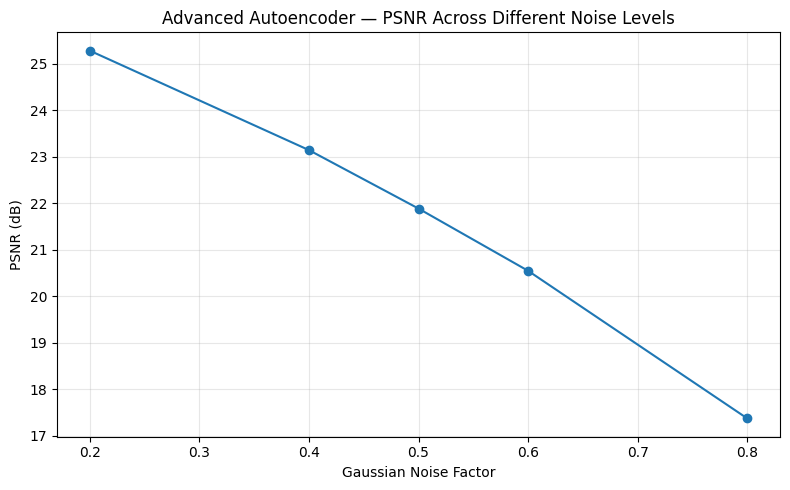

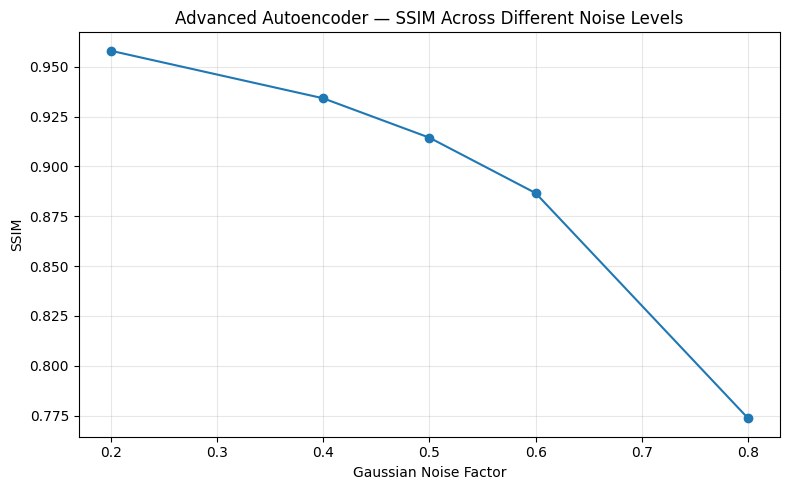


Robustness results saved as 'advanced_autoencoder_robustness_results.csv'
Quantitative robustness evaluation completed successfully.


In [16]:
print("=" * 80)
print("QUANTITATIVE ROBUSTNESS EVALUATION ACROSS NOISE LEVELS")
print("=" * 80)

robustness_results = []

for index, noise_factor in enumerate(noise_levels):

    print(f"\nEvaluating Noise Factor = {noise_factor} ...")

    # Generate reproducible noisy version of the complete test set
    noisy_test_level = add_noise(
        x_test,
        factor=noise_factor,
        seed=SEED + 100 + index
    )

    # Denoise using the trained Advanced Autoencoder
    denoised_test_level = adv_ae.predict(
        noisy_test_level,
        verbose=0
    )

    denoised_test_level = np.clip(
        denoised_test_level,
        0.0,
        1.0
    )

    # MSE
    mse_value = np.mean(
        (x_test - denoised_test_level) ** 2
    )

    # Mean PSNR across all test images
    psnr_value = np.mean([
        psnr(
            x_test[i].squeeze(),
            denoised_test_level[i].squeeze(),
            data_range=1.0
        )
        for i in range(len(x_test))
    ])

    # Mean SSIM across all test images
    ssim_value = np.mean([
        ssim(
            x_test[i].squeeze(),
            denoised_test_level[i].squeeze(),
            data_range=1.0
        )
        for i in range(len(x_test))
    ])

    robustness_results.append({
        "Noise Factor": noise_factor,
        "MSE": mse_value,
        "PSNR (dB)": psnr_value,
        "SSIM": ssim_value
    })


# Create results table
robustness_df = pd.DataFrame(
    robustness_results
)


print("\n" + "=" * 80)
print("ROBUSTNESS PERFORMANCE SUMMARY")
print("=" * 80)

print(
    robustness_df.to_string(
        index=False,
        formatters={
            "Noise Factor": "{:.1f}".format,
            "MSE": "{:.6f}".format,
            "PSNR (dB)": "{:.2f}".format,
            "SSIM": "{:.4f}".format
        }
    )
)


# Plot PSNR across noise levels
plt.figure(figsize=(8, 5))

plt.plot(
    robustness_df["Noise Factor"],
    robustness_df["PSNR (dB)"],
    marker="o"
)

plt.xlabel("Gaussian Noise Factor")
plt.ylabel("PSNR (dB)")
plt.title(
    "Advanced Autoencoder — PSNR Across Different Noise Levels"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "robustness_psnr_across_noise_levels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Plot SSIM across noise levels
plt.figure(figsize=(8, 5))

plt.plot(
    robustness_df["Noise Factor"],
    robustness_df["SSIM"],
    marker="o"
)

plt.xlabel("Gaussian Noise Factor")
plt.ylabel("SSIM")
plt.title(
    "Advanced Autoencoder — SSIM Across Different Noise Levels"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "robustness_ssim_across_noise_levels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Save results
robustness_df.to_csv(
    "advanced_autoencoder_robustness_results.csv",
    index=False
)

print(
    "\nRobustness results saved as "
    "'advanced_autoencoder_robustness_results.csv'"
)

print(
    "Quantitative robustness evaluation completed successfully."
)

### Quantitative Robustness Observation

The results show that the **Advanced Skip-Connection Autoencoder** maintains strong denoising performance across different Gaussian noise levels, although reconstruction quality gradually decreases as the noise becomes more severe.

At a noise factor of **0.2**, the model achieves its best performance with an MSE of **0.003259**, PSNR of **25.28 dB**, and SSIM of **0.9580**. At the training noise factor of **0.5**, it still performs well, achieving an MSE of **0.007133**, PSNR of **21.88 dB**, and SSIM of **0.9144**. Even under the highest tested noise factor of **0.8**, the model retains meaningful denoising capability with an MSE of **0.020227**, PSNR of **17.37 dB**, and SSIM of **0.7736**.

Overall, the results indicate that as the Gaussian noise factor increases, **MSE increases while PSNR and SSIM decrease**, reflecting the expected decline in reconstruction quality. The gradual performance degradation demonstrates that the model generalizes well across different Gaussian noise intensities, although this evaluation is limited to Gaussian noise and does not extend to other noise types.


## Step 17. Save the Best-Performing Model

Based on the final quantitative evaluation, the **Advanced Skip-Connection Autoencoder** delivered the best denoising performance among all trained models, achieving the lowest MSE and the highest PSNR and SSIM.

The best-performing model is therefore saved for future inference, evaluation, or deployment without the need for retraining.

The model is stored using the native **Keras `.keras` format**, which preserves the complete model architecture, learned weights, and configuration.


In [18]:
adv_ae.save("week6_mohammed_azim_ajaz_shaikh_denoising_autoencoder_advanced.keras")

print("=" * 70)
print("WINNING MODEL SAVED SUCCESSFULLY")
print("=" * 70)

print("\nModel File : week6_mohammed_azim_ajaz_shaikh_denoising_autoencoder_advanced.keras")
print("Model      : Advanced Skip-Connection Autoencoder")
print("Status     : Saved successfully")

print("\nThe trained model can now be loaded for future inference")
print("without retraining the network.")

# Uncomment the following lines to download the model from Google Colab:
# from google.colab import files
# files.download("week6_mohammed_azim_ajaz_shaikh_denoising_autoencoder_advanced.keras")

WINNING MODEL SAVED SUCCESSFULLY

Model File : week6_mohammed_azim_ajaz_shaikh_denoising_autoencoder_advanced.keras
Model      : Advanced Skip-Connection Autoencoder
Status     : Saved successfully

The trained model can now be loaded for future inference
without retraining the network.


## Step 18. Conclusion

This project developed and evaluated three autoencoder architectures for removing Gaussian noise from MNIST handwritten digit images: the **Dense Autoencoder**, **Convolutional Autoencoder**, and **Advanced Skip-Connection Autoencoder**.

The results showed that the **Advanced Skip-Connection Autoencoder** delivered the best denoising performance, achieving the lowest MSE and the highest PSNR and SSIM among all models. Additional experiments demonstrated that the model remained effective across different noise levels, while the ensemble approach did not outperform the advanced model.

Overall, the project successfully achieved its objective of reconstructing clean MNIST images from noisy inputs, with the **Advanced Skip-Connection Autoencoder** selected as the final model for future inference and evaluation.
